In [2]:
import pandas as pd

df = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    object 
 2   customer_name  508 non-null    object 
 3   city           508 non-null    object 
 4   category       508 non-null    object 
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    object 
 9   status         508 non-null    object 
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), object(6)
memory usage: 43.8+ KB


In [5]:
df.describe()

,order_id,product_id,quantity,amount_inr,rating
count,508.000000,508.000000,508.000000,498.000000,439.000000
mean,250.204724,15.476378,3.045276,257.530120,3.082005
std,144.594139,8.747467,1.364497,559.424136,1.364126
min,1.000000,1.000000,1.000000,20.000000,1.000000
25%,125.750000,8.000000,2.000000,90.000000,2.000000
50%,249.500000,15.000000,3.000000,168.000000,3.000000
75%,376.250000,23.000000,4.000000,283.750000,4.000000
max,500.000000,30.000000,5.000000,7600.000000,5.000000


In [6]:
df["status"].value_counts()

,count
status,
Delivered,439
Cancelled,43
Pending,26


### Initial Data Quality Observations

Before cleaning the data, I observed the following issues:

- The dataset contains more than 500 rows, indicating that duplicate order records may be present.
- The `city` and `category` columns contain inconsistent casing and/or whitespace.
- The `amount_inr` column contains missing values.
- Some `amount_inr` values appear unusually large and may be statistical outliers.
- The `rating` column contains missing values, which will need to be checked against the order status before deciding whether they represent a data-quality issue.

In [7]:
df["order_id"].duplicated().sum()

np.int64(8)

In [8]:
df = df.drop_duplicates(subset="order_id", keep="first")

In [9]:
df.shape

(500, 11)

In [10]:
df["city"].unique()

array(['Pune', 'Bengaluru', 'Hyderabad', 'Mumbai', ' Bengaluru ',
       'BENGALURU', ' Mumbai ', 'HYDERABAD', 'mumbai', 'MUMBAI', ' Pune ',
       ' Hyderabad ', 'bengaluru', 'PUNE'], dtype=object)

In [11]:
df["city"] = df["city"].str.strip().str.title()

In [12]:
df["city"].unique()

array(['Pune', 'Bengaluru', 'Hyderabad', 'Mumbai'], dtype=object)

In [13]:
df["category"].unique()

array(['Snacks & Beverages', 'Household Essentials', 'Bakery',
       'Personal Care', 'Fruits & Vegetables', 'Dairy & Eggs',
       ' Dairy & Eggs ', 'BAKERY', ' Household Essentials ',
       'DAIRY & EGGS', ' Bakery ', 'SNACKS & BEVERAGES', 'dairy & eggs',
       'HOUSEHOLD ESSENTIALS', ' Personal Care ', 'FRUITS & VEGETABLES',
       ' Fruits & Vegetables ', 'snacks & beverages'], dtype=object)

In [14]:
df["category"] = df["category"].str.strip().str.title()

In [15]:
df["category"].unique()

array(['Snacks & Beverages', 'Household Essentials', 'Bakery',
       'Personal Care', 'Fruits & Vegetables', 'Dairy & Eggs'],
      dtype=object)

In [16]:
df["amount_inr"].isna().sum()

np.int64(10)

In [17]:
revenue_df = df[df["amount_inr"].notna()].copy()

In [18]:
df.groupby("status")["rating"].apply(lambda x: x.isna().sum())

,rating
status,
Cancelled,42
Delivered,0
Pending,24


In [19]:
delivered_revenue = df[
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna())
]["amount_inr"]

Q1 = delivered_revenue.quantile(0.25)
Q3 = delivered_revenue.quantile(0.75)

IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper fence:", upper_fence)

Q1: 90.0
Q3: 275.0
IQR: 185.0
Upper fence: 552.5


In [20]:
outlier_count = (
    (df["status"] == "Delivered") &
    (df["amount_inr"].notna()) &
    (df["amount_inr"] > upper_fence)
).sum()

print("Number of outliers above upper fence:", outlier_count)

Number of outliers above upper fence: 16


In [21]:
df.loc[
    (df["status"] == "Delivered") & (df["amount_inr"].notna()),
    "amount_inr"
] = df.loc[
    (df["status"] == "Delivered") & (df["amount_inr"].notna()),
    "amount_inr"
].clip(upper=upper_fence)

In [22]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [23]:
df["month"] = df["order_date"].dt.month

In [24]:
df["month_name"] = df["order_date"].dt.month_name()

In [25]:
df["revenue_per_unit"] = df["amount_inr"] / df["quantity"]

In [26]:
df["is_delivered"] = df["status"] == "Delivered"

In [27]:
category_revenue = (
    df[df["is_delivered"] & df["amount_inr"].notna()]
    .groupby("category")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(category_revenue)

category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64


In [28]:
top_category = category_revenue.idxmax()
top_category_revenue = category_revenue.max()

print("Top category:", top_category)
print("Revenue:", top_category_revenue)

Top category: Household Essentials
Revenue: 20910.0


In [29]:
df_merged = pd.merge(
    df,
    products[["product_id", "supplier"]],
    on="product_id",
    how="left"
)

df_merged.head()

,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating,month,month_name,revenue_per_unit,is_delivered,supplier
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0,3,March,35.0,True,BakeHouse Supplies
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0,5,May,60.0,True,BakeHouse Supplies
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0,6,June,75.0,True,HomeEssentials Traders
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0,3,March,30.0,True,SnackHub India
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0,4,April,110.0,True,SnackHub India


In [30]:
supplier_revenue = (
    df_merged[
        (df_merged["is_delivered"]) &
        (df_merged["amount_inr"].notna())
    ]
    .groupby("supplier")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print(supplier_revenue)

supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64


In [31]:
top_supplier = supplier_revenue.idxmax()
top_supplier_revenue = supplier_revenue.max()

print("Top supplier:", top_supplier)
print("Revenue:", top_supplier_revenue)

Top supplier: HomeEssentials Traders
Revenue: 20910.0


In [32]:
monthly_revenue = (
    df[
        (df["is_delivered"]) &
        (df["amount_inr"].notna())
    ]
    .groupby(["month", "month_name"])["amount_inr"]
    .sum()
    .reset_index()
    .sort_values("month")
)

print(monthly_revenue)

   month month_name  amount_inr
0      1    January     10059.5
1      2   February     13715.0
2      3      March     14747.5
3      4      April     16558.5
4      5        May     16668.5
5      6       June     12888.0


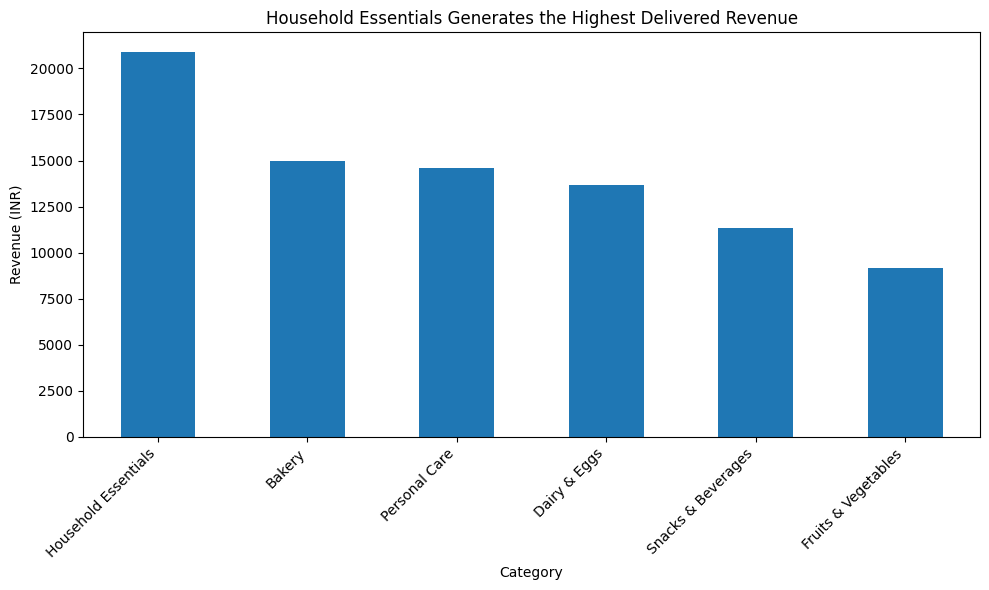

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Household Essentials Generates the Highest Delivered Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

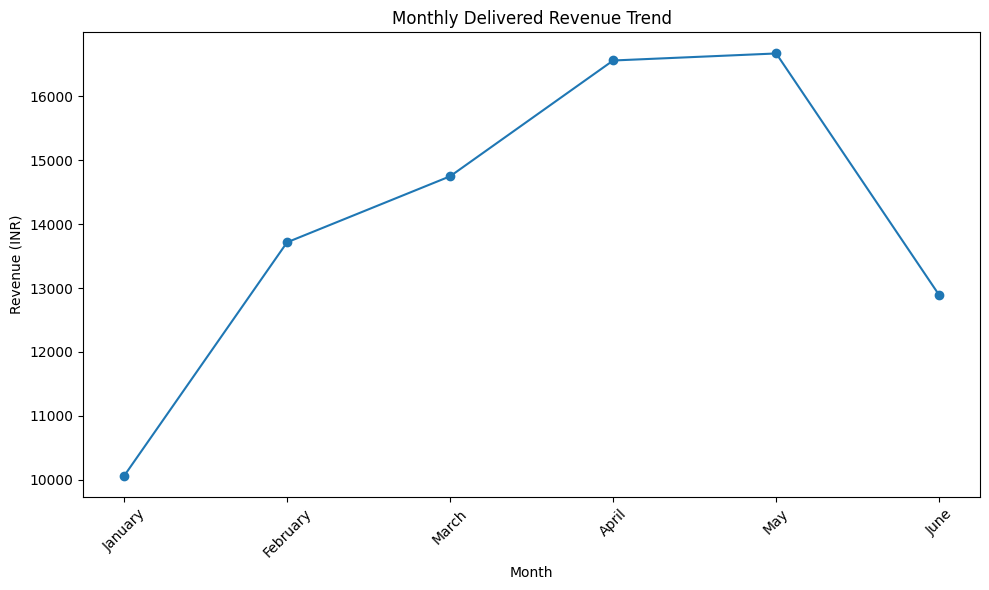

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue["month_name"],
    monthly_revenue["amount_inr"],
    marker="o"
)

plt.title("Monthly Delivered Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

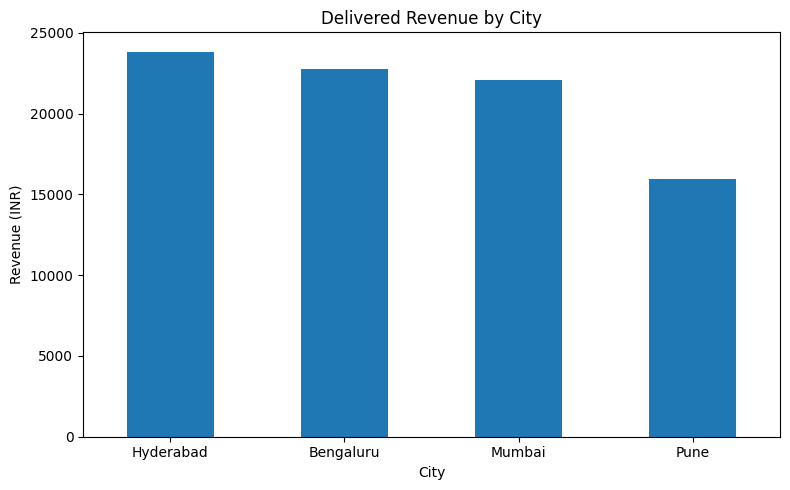

In [35]:
city_revenue = (
    df[
        (df["is_delivered"]) &
        (df["amount_inr"].notna())
    ]
    .groupby("city")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

city_revenue.plot(kind="bar")

plt.title("Delivered Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [36]:
print("Top category:", top_category)
print("Top category revenue:", top_category_revenue)
print("Top supplier:", top_supplier)
print("Top supplier revenue:", top_supplier_revenue)
print("Number of cities:", df["city"].nunique())
print("Number of categories:", df["category"].nunique())

Top category: Household Essentials
Top category revenue: 20910.0
Top supplier: HomeEssentials Traders
Top supplier revenue: 20910.0
Number of cities: 4
Number of categories: 6


### Key Observations

#### 1. Category Performance
**What:** Household Essentials is the highest-revenue category based on Delivered orders.

**Why it matters:** This indicates strong customer demand for Household Essentials and makes it an important category for business performance.

**Next step:** Maintain strong availability and consider expanding the assortment of high-performing Household Essentials products.

#### 2. Supplier Performance
**What:** HomeEssentials Traders is the highest-revenue supplier based on Delivered orders.

**Why it matters:** The supplier contributes significantly to revenue and may be strategically important for maintaining product availability.

**Next step:** Monitor this supplier's inventory and fulfillment performance closely and evaluate opportunities to strengthen the supplier relationship.

#### 3. Geographic Performance
**What:** Delivered revenue varies across the four cities in the dataset.

**Why it matters:** Differences in city-level revenue can indicate variations in customer demand and category performance across markets.

**Next step:** Compare the highest- and lowest-revenue cities to identify opportunities for targeted assortment, promotions, and inventory planning.

## AI Prompt 2 — Pandas Data Cleaning and Analysis

### Role
Act as a data analyst experienced in Pandas and retail category performance analysis.

### Context
I am analyzing a BigBasket-style order dataset containing order details, product categories, cities, order status, quantities, revenue, ratings, and product supplier information. The raw data contains duplicate orders, inconsistent text formatting, missing revenue values, and unusually large revenue values.

### Task
Provide Pandas code to:
1. Remove duplicate orders using `order_id`, keeping the first record.
2. Standardize `city` and `category` using whitespace stripping and title casing.
3. Identify missing `amount_inr` values without replacing them.
4. Detect Delivered-order revenue outliers using the IQR method.
5. Cap revenue values above the upper IQR fence.
6. Parse `order_date` and create month-related fields.
7. Calculate revenue per unit and identify Delivered orders.
8. Calculate revenue by category and supplier.

### Constraints
- Do not fill missing revenue values with zero or another value.
- Do not remove IQR outliers; cap them using the upper fence.
- Revenue calculations must use Delivered orders with non-null revenue.
- Keep rating nulls for Cancelled and Pending orders.
- Use Pandas operations and keep the analysis reproducible.

### Format
Provide clear, executable Pandas code with brief explanations for each major step.

### Verification Performed
I verified the resulting analysis by checking:
- The dataset contains exactly 500 rows after deduplication.
- City values were standardized to exactly 4 cities.
- Category values were standardized to exactly 6 categories.
- Missing revenue values were excluded from revenue calculations.
- Delivered revenue outliers were capped using the IQR upper fence.
- Household Essentials was identified as the top-revenue category.
- HomeEssentials Traders was identified as the top-revenue supplier.

In [37]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Cities:", sorted(df["city"].unique()))
print("Number of cities:", df["city"].nunique())
print("Categories:", sorted(df["category"].unique()))
print("Number of categories:", df["category"].nunique())
print("Missing amount_inr:", df["amount_inr"].isna().sum())
print("Top category:", top_category)
print("Top supplier:", top_supplier)
print("Outliers capped:", outlier_count)

Rows: 500
Columns: 15
Cities: ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Number of cities: 4
Categories: ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
Number of categories: 6
Missing amount_inr: 10
Top category: Household Essentials
Top supplier: HomeEssentials Traders
Outliers capped: 16
